<a href="https://colab.research.google.com/github/jvexxxx/verrt/blob/main/flux_lora_quant_blogpost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optionally mount to google drive to save results

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

FOLDERNAME = 'flux_lora_quant' # path to folder
assert FOLDERNAME is not None, "[!] Enter the foldername."

folder_path = '/content/drive/My Drive/{}'.format(FOLDERNAME)

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Created folder: {folder_path}")

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content/drive/My\ Drive/$FOLDERNAME

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/flux_lora_quant


# Fine-Tuning FLUX.1-dev on consumer hardware and in FP8

In our previous post, [Exploring Quantization Backends in Diffusers](https://huggingface.co/blog/diffusers-quantization), we dived into how various quantization techniques can shrink diffusion models like FLUX.1-dev, making them significantly more accessible for *inference* without drastically compromising performance. We saw how `bitsandbytes`, `torchao`, and others reduce memory footprints for generating images.

Performing inference is cool but to make these models truly our own, we also need to be able to fine-tune them. Therefore, in this post, we tackle **efficient** *fine-tuning* of these models with peak memory use under ~10 GB of VRAM on a single GPU. This post will guide you through fine-tuning FLUX.1-dev using QLoRA with the Hugging Face `diffusers` library. We'll showcase results from an NVIDIA RTX 4090. We'll also highlight how FP8 training with `torchao` can further optimize speed on compatible hardware.

This Colab notebook provides all the code necessary to run the training and inference process described in the blog post (But, has been slightly modified so that it is able to run on T4 GPU in a reasonable amount of time)

### Setup

First, let's install the required libraries.

In [1]:
!curl -LsSf https://astral.sh/uv/install.sh | sh

downloading uv 0.12.6 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!


In [2]:
!uv pip install -q diffusers accelerate bitsandbytes wandb datasets==2.19.0

Logging in to the Hugging Face Hub is required as black-forest-labs/FLUX.1-dev is gated and to push your trained LoRA adapter to the Hub at the end

In [3]:
from huggingface_hub import notebook_login

notebook_login()

You can optionally log into wandb if you want to report to wandb

In [4]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: ERROR Invalid API key: API key must have 40+ characters, has 37.
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: manualdomundofan (manualdomundofan-none) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
import pandas as pd
import torch
from datasets import load_dataset
from huggingface_hub.utils import insecure_hashlib
from tqdm.auto import tqdm
from transformers import T5EncoderModel

from diffusers import FluxPipeline


MAX_SEQ_LENGTH = 77
OUTPUT_PATH = "embeddings_alphonse_mucha.parquet"
DATASET_NAME = "derekl35/alphonse-mucha-style"
MODEL_ID = "black-forest-labs/FLUX.1-dev"

def generate_image_hash(image):
    return insecure_hashlib.sha256(image.tobytes()).hexdigest()


def load_flux_dev_pipeline():
    id = "black-forest-labs/FLUX.1-dev"
    text_encoder = T5EncoderModel.from_pretrained(id, subfolder="text_encoder_2", load_in_8bit=True, device_map="auto")
    pipeline = FluxPipeline.from_pretrained(
        id, text_encoder_2=text_encoder, transformer=None, vae=None, device_map="balanced"
    )
    return pipeline


@torch.no_grad()
def compute_embeddings(pipeline, prompts, max_sequence_length):
    all_prompt_embeds = []
    all_pooled_prompt_embeds = []
    all_text_ids = []
    for prompt in tqdm(prompts, desc="Encoding prompts."):
        (
            prompt_embeds,
            pooled_prompt_embeds,
            text_ids,
        ) = pipeline.encode_prompt(prompt=prompt, prompt_2=None, max_sequence_length=max_sequence_length)
        all_prompt_embeds.append(prompt_embeds)
        all_pooled_prompt_embeds.append(pooled_prompt_embeds)
        all_text_ids.append(text_ids)

    max_memory = torch.cuda.max_memory_allocated() / 1024 / 1024 / 1024
    print(f"Max memory allocated: {max_memory:.3f} GB")
    return all_prompt_embeds, all_pooled_prompt_embeds, all_text_ids


def run():
    dataset = load_dataset(DATASET_NAME, split="train")
    image_prompts = {generate_image_hash(sample["image"]): sample["text"] for sample in dataset}
    all_prompts = list(image_prompts.values())
    print(f"{len(all_prompts)=}")

    pipeline = load_flux_dev_pipeline()
    all_prompt_embeds, all_pooled_prompt_embeds, all_text_ids = compute_embeddings(
        pipeline, all_prompts, MAX_SEQ_LENGTH
    )

    data = []
    for i, (image_hash, _) in enumerate(image_prompts.items()):
        data.append((image_hash, all_prompt_embeds[i], all_pooled_prompt_embeds[i], all_text_ids[i]))
    print(f"{len(data)=}")

    # Create a DataFrame
    embedding_cols = ["prompt_embeds", "pooled_prompt_embeds", "text_ids"]
    df = pd.DataFrame(data, columns=["image_hash"] + embedding_cols)
    print(f"{len(df)=}")

    # Convert embedding lists to arrays (for proper storage in parquet)
    for col in embedding_cols:
        df[col] = df[col].apply(lambda x: x.cpu().numpy().flatten().tolist())

    # Save the dataframe to a parquet file
    df.to_parquet(OUTPUT_PATH)
    print(f"Data successfully serialized to {OUTPUT_PATH}")

    del pipeline
    del dataset
    del image_prompts
    del all_prompts
    del all_prompt_embeds
    del all_pooled_prompt_embeds
    del all_text_ids
    del df
    torch.cuda.empty_cache()


run()

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Generating train split:   0%|          | 0/13 [00:00<?, ? examples/s]

len(all_prompts)=13


config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/19.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
import copy
import logging
import math
import os
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import torch
import transformers
from accelerate import Accelerator, DistributedType
from accelerate.logging import get_logger
from accelerate.utils import DistributedDataParallelKwargs, ProjectConfiguration, set_seed
from datasets import load_dataset
from huggingface_hub.utils import insecure_hashlib
from peft import LoraConfig, prepare_model_for_kbit_training, set_peft_model_state_dict
from peft.utils import get_peft_model_state_dict
from PIL.ImageOps import exif_transpose
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms.functional import crop
from tqdm.auto import tqdm

import diffusers
from diffusers import (
    AutoencoderKL, BitsAndBytesConfig, FlowMatchEulerDiscreteScheduler,
    FluxPipeline, FluxTransformer2DModel,
)
from diffusers.optimization import get_scheduler
from diffusers.training_utils import (
    cast_training_params, compute_density_for_timestep_sampling,
    compute_loss_weighting_for_sd3, free_memory,
)
from diffusers.utils import convert_unet_state_dict_to_peft, is_wandb_available
from diffusers.utils.torch_utils import is_compiled_module

logger = get_logger(__name__)

class DreamBoothDataset(Dataset):
    def __init__(self, data_df_path, dataset_name, width, height, max_sequence_length=77):
        self.width, self.height, self.max_sequence_length = width, height, max_sequence_length
        self.data_df_path = Path(data_df_path)
        if not self.data_df_path.exists():
            raise ValueError("`data_df_path` doesn't exists.")

        dataset = load_dataset(dataset_name, split="train")
        self.instance_images = [sample["image"] for sample in dataset]
        self.image_hashes = [insecure_hashlib.sha256(img.tobytes()).hexdigest() for img in self.instance_images]
        self.pixel_values = self._apply_transforms()
        self.data_dict = self._map_embeddings()
        self._length = len(self.instance_images)

    def __len__(self):
        return self._length

    def __getitem__(self, index):
        idx = index % len(self.instance_images)
        hash_key = self.image_hashes[idx]
        prompt_embeds, pooled_prompt_embeds, text_ids = self.data_dict[hash_key]
        return {
            "instance_images": self.pixel_values[idx],
            "prompt_embeds": prompt_embeds,
            "pooled_prompt_embeds": pooled_prompt_embeds,
            "text_ids": text_ids,
        }

    def _apply_transforms(self):
        transform = transforms.Compose([
            transforms.Resize((self.height, self.width), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.RandomCrop((self.height, self.width)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

        pixel_values = []
        for image in self.instance_images:
            image = exif_transpose(image).convert("RGB") if image.mode != "RGB" else exif_transpose(image)
            pixel_values.append(transform(image))
        return pixel_values

    def _map_embeddings(self):
        df = pd.read_parquet(self.data_df_path)
        data_dict = {}
        for _, row in df.iterrows():
            prompt_embeds = torch.from_numpy(np.array(row["prompt_embeds"]).reshape(self.max_sequence_length, 4096))
            pooled_prompt_embeds = torch.from_numpy(np.array(row["pooled_prompt_embeds"]).reshape(768))
            text_ids = torch.from_numpy(np.array(row["text_ids"]).reshape(77, 3))
            data_dict[row["image_hash"]] = (prompt_embeds, pooled_prompt_embeds, text_ids)
        return data_dict

def collate_fn(examples):
    pixel_values = torch.stack([ex["instance_images"] for ex in examples]).float()
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
    prompt_embeds = torch.stack([ex["prompt_embeds"] for ex in examples])
    pooled_prompt_embeds = torch.stack([ex["pooled_prompt_embeds"] for ex in examples])
    text_ids = torch.stack([ex["text_ids"] for ex in examples])[0]

    return {
        "pixel_values": pixel_values,
        "prompt_embeds": prompt_embeds,
        "pooled_prompt_embeds": pooled_prompt_embeds,
        "text_ids": text_ids,
    }

def main(args):
    # Setup accelerator
    accelerator = Accelerator(
        gradient_accumulation_steps=args.gradient_accumulation_steps,
        mixed_precision=args.mixed_precision,
        log_with=args.report_to,
        project_config=ProjectConfiguration(project_dir=args.output_dir, logging_dir=Path(args.output_dir, "logs")),
        kwargs_handlers=[DistributedDataParallelKwargs(find_unused_parameters=True)],
    )

    # Setup logging
    logging.basicConfig(format="%(asctime)s - %(levelname)s - %(name)s - %(message)s", level=logging.INFO)
    if accelerator.is_local_main_process:
        transformers.utils.logging.set_verbosity_warning()
        diffusers.utils.logging.set_verbosity_info()
    else:
        transformers.utils.logging.set_verbosity_error()
        diffusers.utils.logging.set_verbosity_error()

    set_seed(args.seed) if args.seed is not None else None
    os.makedirs(args.output_dir, exist_ok=True) if accelerator.is_main_process else None

    # Load models with quantization
    noise_scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(args.pretrained_model_name_or_path, subfolder="scheduler")
    noise_scheduler_copy = copy.deepcopy(noise_scheduler)

    vae = AutoencoderKL.from_pretrained(args.pretrained_model_name_or_path, subfolder="vae")

    nf4_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
    transformer = FluxTransformer2DModel.from_pretrained(
        args.pretrained_model_name_or_path, subfolder="transformer",
        quantization_config=nf4_config, torch_dtype=torch.float16
    )
    transformer = prepare_model_for_kbit_training(transformer, use_gradient_checkpointing=False)

    # Freeze models and setup LoRA
    transformer.requires_grad_(False)
    vae.requires_grad_(False)
    vae.to(accelerator.device, dtype=torch.float16)
    if args.gradient_checkpointing:
        transformer.enable_gradient_checkpointing()

    # now we will add new LoRA weights to the attention layers
    transformer_lora_config = LoraConfig(
        r=args.rank,
        lora_alpha=args.rank,
        init_lora_weights="gaussian",
        target_modules=["to_k", "to_q", "to_v", "to_out.0"],
    )
    transformer.add_adapter(transformer_lora_config)

    print(f"trainable params: {transformer.num_parameters(only_trainable=True)} || all params: {transformer.num_parameters()}")

    # Setup optimizer
    import bitsandbytes as bnb
    optimizer = bnb.optim.AdamW8bit(
        [{"params": list(filter(lambda p: p.requires_grad, transformer.parameters())), "lr": args.learning_rate}],
        betas=(0.9, 0.999), weight_decay=1e-04, eps=1e-08
    )

    # Setup dataset and dataloader
    train_dataset = DreamBoothDataset(args.data_df_path, "derekl35/alphonse-mucha-style", args.width, args.height)
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=args.train_batch_size, shuffle=True, collate_fn=collate_fn
    )

    # Cache latents
    vae_config = vae.config
    latents_cache = []
    for batch in tqdm(train_dataloader, desc="Caching latents"):
        with torch.no_grad():
            pixel_values = batch["pixel_values"].to(accelerator.device, dtype=torch.float16)
            latents_cache.append(vae.encode(pixel_values).latent_dist)

    del vae
    free_memory()

    # Setup scheduler and training steps
    num_update_steps_per_epoch = math.ceil(len(train_dataloader) / args.gradient_accumulation_steps)
    args.max_train_steps = args.max_train_steps or args.num_train_epochs * num_update_steps_per_epoch

    args.num_train_epochs = math.ceil(args.max_train_steps / num_update_steps_per_epoch)

    lr_scheduler = get_scheduler("constant", optimizer=optimizer, num_warmup_steps=0, num_training_steps=args.max_train_steps)

    # Prepare for training
    transformer, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(transformer, optimizer, train_dataloader, lr_scheduler)

    # Register save/load hooks
    def unwrap_model(model):
        model = accelerator.unwrap_model(model)
        return model._orig_mod if is_compiled_module(model) else model

    def save_model_hook(models, weights, output_dir):
        if accelerator.is_main_process:
            for model in models:
                if isinstance(unwrap_model(model), type(unwrap_model(transformer))):
                    lora_layers = get_peft_model_state_dict(unwrap_model(model))
                    FluxPipeline.save_lora_weights(output_dir, transformer_lora_layers=lora_layers, text_encoder_lora_layers=None)
                    weights.pop() if weights else None

    accelerator.register_save_state_pre_hook(save_model_hook)
    cast_training_params([transformer], dtype=torch.float32) if args.mixed_precision == "fp16" else None

    # Initialize tracking
    accelerator.init_trackers("dreambooth-flux-dev-lora-alphonse-mucha", config=vars(args)) if accelerator.is_main_process else None

    # Training loop
    def get_sigmas(timesteps, n_dim=4, dtype=torch.float32):
        sigmas = noise_scheduler_copy.sigmas.to(device=accelerator.device, dtype=dtype)
        schedule_timesteps = noise_scheduler_copy.timesteps.to(accelerator.device)
        step_indices = [(schedule_timesteps == t).nonzero().item() for t in timesteps.to(accelerator.device)]
        sigma = sigmas[step_indices].flatten()
        while len(sigma.shape) < n_dim:
            sigma = sigma.unsqueeze(-1)
        return sigma

    global_step = 0
    progress_bar = tqdm(range(args.max_train_steps), desc="Steps", disable=not accelerator.is_local_main_process)

    for epoch in range(args.num_train_epochs):
        for step, batch in enumerate(train_dataloader):
            with accelerator.accumulate([transformer]):
                # Get cached latents
                model_input = latents_cache[step].sample()
                model_input = (model_input - vae_config.shift_factor) * vae_config.scaling_factor
                model_input = model_input.to(dtype=torch.float16)

                # Prepare inputs
                latent_image_ids = FluxPipeline._prepare_latent_image_ids(
                    model_input.shape[0], model_input.shape[2] // 2, model_input.shape[3] // 2,
                    accelerator.device, torch.float16
                )

                noise = torch.randn_like(model_input)
                bsz = model_input.shape[0]

                u = compute_density_for_timestep_sampling("none", bsz, 0.0, 1.0, 1.29)
                indices = (u * noise_scheduler_copy.config.num_train_timesteps).long()
                timesteps = noise_scheduler_copy.timesteps[indices].to(device=model_input.device)

                sigmas = get_sigmas(timesteps, n_dim=model_input.ndim, dtype=model_input.dtype)
                noisy_model_input = (1.0 - sigmas) * model_input + sigmas * noise

                packed_noisy_model_input = FluxPipeline._pack_latents(
                    noisy_model_input, model_input.shape[0], model_input.shape[1],
                    model_input.shape[2], model_input.shape[3]
                )

                # Forward pass
                guidance = torch.tensor([args.guidance_scale], device=accelerator.device).expand(bsz) if unwrap_model(transformer).config.guidance_embeds else None

                model_pred = transformer(
                    hidden_states=packed_noisy_model_input,
                    timestep=timesteps / 1000,
                    guidance=guidance,
                    pooled_projections=batch["pooled_prompt_embeds"].to(accelerator.device, dtype=torch.float16),
                    encoder_hidden_states=batch["prompt_embeds"].to(accelerator.device, dtype=torch.float16),
                    txt_ids=batch["text_ids"].to(accelerator.device, dtype=torch.float16),
                    img_ids=latent_image_ids,
                    return_dict=False,
                )[0]

                vae_scale_factor = 2 ** (len(vae_config.block_out_channels) - 1)
                model_pred = FluxPipeline._unpack_latents(
                    model_pred, model_input.shape[2] * vae_scale_factor,
                    model_input.shape[3] * vae_scale_factor, vae_scale_factor
                )

                # Compute loss
                weighting = compute_loss_weighting_for_sd3("none", sigmas)
                target = noise - model_input
                loss = torch.mean((weighting.float() * (model_pred.float() - target.float()) ** 2).reshape(target.shape[0], -1), 1).mean()

                accelerator.backward(loss)

                if accelerator.sync_gradients:
                    accelerator.clip_grad_norm_(transformer.parameters(), 1.0)

                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1

                # Checkpointing
                if global_step % args.checkpointing_steps == 0 and (accelerator.is_main_process or accelerator.distributed_type == DistributedType.DEEPSPEED):
                    save_path = os.path.join(args.output_dir, f"checkpoint-{global_step}")
                    accelerator.save_state(save_path)

            # Logging
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0]}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)

            if global_step >= args.max_train_steps:
                break

    # Final save
    accelerator.wait_for_everyone()
    if accelerator.is_main_process:
        transformer_lora_layers = get_peft_model_state_dict(unwrap_model(transformer))
        FluxPipeline.save_lora_weights(args.output_dir, transformer_lora_layers=transformer_lora_layers, text_encoder_lora_layers=None)

    if torch.cuda.is_available():
        print(f"Pipeline memory usage: {torch.cuda.max_memory_reserved() / 1024**3:.3f} GB")
    else:
        print("Training completed. GPU not available for memory tracking.")

    accelerator.end_training()

if __name__ == "__main__":
    class Args:
        pretrained_model_name_or_path = "black-forest-labs/FLUX.1-dev"
        data_df_path = "embeddings_alphonse_mucha.parquet"
        output_dir = "alphonse_mucha_lora_flux_nf4"
        mixed_precision = "fp16"
        weighting_scheme = "none"
        width, height = 512, 768
        train_batch_size = 1
        learning_rate = 1e-4
        guidance_scale = 1.0
        report_to = "wandb"
        gradient_accumulation_steps = 4
        gradient_checkpointing = True
        rank = 4
        max_train_steps = 100
        seed = 0
        checkpointing_steps = 100

    main(Args())
    # clear memory
    # del transformer
    torch.cuda.empty_cache()

{'time_shift_type', 'use_karras_sigmas', 'invert_sigmas', 'shift_terminal', 'use_exponential_sigmas', 'use_beta_sigmas'} was not found in config. Values will be initialized to default values.
All model checkpoint weights were used when initializing AutoencoderKL.

All the weights of AutoencoderKL were initialized from the model checkpoint at black-forest-labs/FLUX.1-dev.
If your task is similar to the task the model of the checkpoint was trained on, you can already use AutoencoderKL for predictions without further training.
The device_map was not initialized. Setting device_map to {: {current_device}}. If you want to use the model for inference, please set device_map ='auto' 


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Instantiating FluxTransformer2DModel model under default dtype torch.float16.
{'out_channels', 'axes_dims_rope'} was not found in config. Values will be initialized to default values.


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

All model checkpoint weights were used when initializing FluxTransformer2DModel.

All the weights of FluxTransformer2DModel were initialized from the model checkpoint at black-forest-labs/FLUX.1-dev.
If your task is similar to the task the model of the checkpoint was trained on, you can already use FluxTransformer2DModel for predictions without further training.


...

wandb: Currently logged in as: derekliu2021 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Steps:   0%|          | 0/700 [00:00<?, ?it/s]

Model weights saved in alphonse_mucha_lora_flux_nf4/checkpoint-100/pytorch_lora_weights.safetensors
Model weights saved in alphonse_mucha_lora_flux_nf4/checkpoint-200/pytorch_lora_weights.safetensors
Model weights saved in alphonse_mucha_lora_flux_nf4/checkpoint-300/pytorch_lora_weights.safetensors
Model weights saved in alphonse_mucha_lora_flux_nf4/checkpoint-400/pytorch_lora_weights.safetensors
Model weights saved in alphonse_mucha_lora_flux_nf4/checkpoint-500/pytorch_lora_weights.safetensors
Model weights saved in alphonse_mucha_lora_flux_nf4/checkpoint-600/pytorch_lora_weights.safetensors
Model weights saved in alphonse_mucha_lora_flux_nf4/checkpoint-700/pytorch_lora_weights.safetensors
Model weights saved in alphonse_mucha_lora_flux_nf4/pytorch_lora_weights.safetensors


Pipeline memory usage: 8.385 GB


loss,▂▄▂▅▆▇▁▅▂▆▃▅▃▅▃▅▁▄█▃▄▃▅▄▅▄▅▂▇▄▃▁▅▅▆▆▅▁▁▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss,0.5993
lr,0.0001


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/28 [00:00<?, ?it/s]

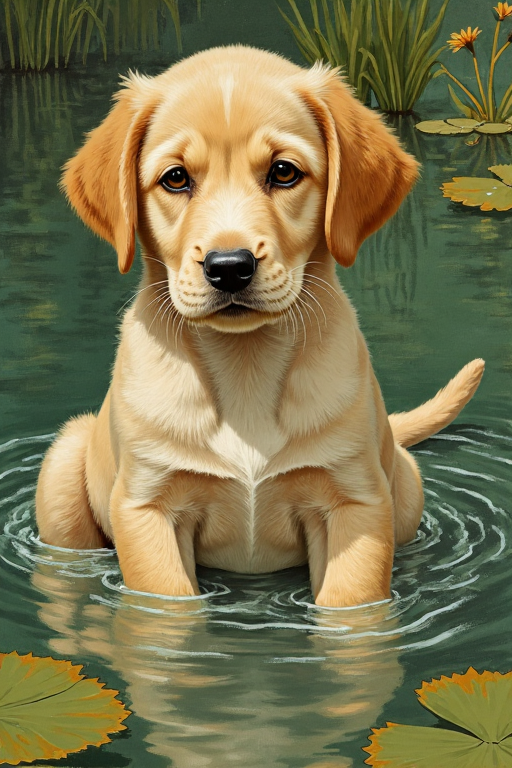

In [ ]:
from diffusers import FluxPipeline, AutoPipelineForText2Image, FluxTransformer2DModel, BitsAndBytesConfig
from transformers import T5EncoderModel
from transformers import BitsAndBytesConfig as TransformersBitsAndBytesConfig
import torch
import gc

ckpt_id = "black-forest-labs/FLUX.1-dev"
lora_path = "alphonse_mucha_lora_flux_nf4"
fused_transformer_path = "fused_transformer"

bnb_4bit_compute_dtype = torch.float16

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=bnb_4bit_compute_dtype,
)

# Load pipeline and fuse LoRA
transformer = FluxTransformer2DModel.from_pretrained(
    ckpt_id, subfolder="transformer",
    quantization_config=nf4_config, torch_dtype=torch.float16
)

quant_config = TransformersBitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)

text_encoder = T5EncoderModel.from_pretrained(ckpt_id, subfolder="text_encoder_2", quantization_config=quant_config, torch_dtype=torch.float16,)

pipeline = FluxPipeline.from_pretrained(
    ckpt_id,
    transformer=transformer,
    text_encoder_2=text_encoder,
    torch_dtype=bnb_4bit_compute_dtype,
)
pipeline.load_lora_weights(lora_path)

del text_encoder
del transformer
gc.collect()
torch.cuda.empty_cache()

pipeline.to("cuda")

prompt = "a puppy in a pond, alphonse mucha style"
image = pipeline(
    prompt,
    num_inference_steps=28,
    guidance_scale=3.5,
    height=768,
    width=512,
    generator=torch.manual_seed(0)
).images[0]

print(f"Pipeline memory usage: {torch.cuda.max_memory_reserved() / 1024**3:.3f} GB")

image.save("alphonse_mucha_lora.png")
image